In [2]:
%load_ext autoreload
%autoreload 2
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# IEEE / Applied Energy Double-Column Formatting Standard
plt.rcParams.update({
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'figure.dpi': 300
})

# Anchor to project root
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

from src.config import SimConfig, EnvConfig
from src.utils.data_processing import load_and_cache_entire_fleet
from src.utils.evaluation import VoyageBenchmarker, print_markdown_table
from src.solvers import AugmentedHybridSDPSolver
from src.plants import AugmentedHybridPlant
from src.controllers import build_approach, AugmentedValueControl

In [3]:
# 1. Environment & Locked Baseline Parameters
env = EnvConfig()
fleet_data = load_and_cache_entire_fleet(env)
exclude_days = [1, 2, 3]

# Baseline configuration established from Notebooks 1 & 2
N_PD = 3        # Dense Markov matrix limit
N_PACK = 4      # Optimal actuator condensation
dP_base = 90.0 # Baseline spatial step [kW]
Dt_base = 180   # Baseline temporal step [s]

value_factory = build_approach(
    controller_cls=AugmentedValueControl,
    plant_cls=AugmentedHybridPlant,
    solver_cls=AugmentedHybridSDPSolver,
    is_macro=False
)

Loading fleet data from binary cache (fleet_data_cache_scale_0.75.npz)...
 -> Cache instantly loaded in 0.079 seconds.


In [11]:
# 2. Part A: Iso-Complexity Combinatorial Search
seconds_in_day = 86400
divisors_86400 = sorted([d for d in range(1, seconds_in_day + 1) if seconds_in_day % d == 0])

def get_exact_complexity(dP, Dt):
    cfg = SimConfig(
        dP=dP, Dt=Dt, N_Pd=N_PD, use_smart_grid=True, n_pack=N_PACK,
        apply_terminal_n_cost=False, apply_terminal_soc_cost=True, alpha_fc=4, verbose=False
    )
    N_d = cfg.N_Pd
    N_n = len(cfg.n_vals)
    N_s = cfg.N_soc
    N_f = len(cfg.pfc_vals)
    N_b = len(cfg.pb_vals)
    S_nodes = N_d * N_n * N_s * N_f
    A_nodes = N_n * N_b
    steps = seconds_in_day / Dt
    return steps * S_nodes * (N_d + A_nodes)

target_complexity = get_exact_complexity(dP_base, Dt_base)
dp_iso_range = range(45,451,30)

iso_configs = []
for dp in dp_iso_range:
    best_dt = min(divisors_86400, key=lambda dt: abs(get_exact_complexity(dp, dt) - target_complexity))
    iso_configs.append({"dP": dp, "Dt": best_dt})

print("--- RUNNING PART A: ISO-COMPLEXITY SWEEP ---")
iso_results = []
for cfg_params in iso_configs:
    cfg = SimConfig(
        dP=cfg_params["dP"], Dt=cfg_params["Dt"], N_Pd=N_PD, use_smart_grid=True,
        n_pack=N_PACK, apply_terminal_n_cost=False, apply_terminal_soc_cost=True, alpha_fc=4
    )
    bm = VoyageBenchmarker(fleet_data, env, cfg, exclude_days)
    report = bm.run_leave_one_out(value_factory)
    avg = report.summary.loc['Average']
    iso_results.append({
        'dP [kW]': cfg_params["dP"],
        'Dt [s]': cfg_params["Dt"],
        'Total Cost [$]': avg['Total Cost [$]'],
        'Offline Compute Time [s]': avg['Offline Compute Time [s]']
    })

df_iso = pd.DataFrame(iso_results).set_index(['dP [kW]', 'Dt [s]'])
print_markdown_table(df_iso)

--- RUNNING PART A: ISO-COMPLEXITY SWEEP ---

⚙️  EMS Configuration Loaded | Smart Grid: ON
 -> dP Step Size       : 45 kW
 -> Module packs size  : 4 modules
 -> Grid Dimensions    : N_d=3, N_n=4, N_soc=51, N_fc=55, N_bat=46
 -> Augmented Space |S|: 33,660 states
 -> Action Space |A|   : 184 actions
 -> Time steps   : 180 steps/day
 -> Est. Big-O Comput. : O(1,132,995,600) operations / day
 -> Est. RAM Footprint : ~116.20 MB

 [Vault] Cache HIT: Markov Chain succesfully loaded for days [5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
 [Vault] Cache HIT: SDP solution succesfully loaded (AugmentedHybridSDPSolver)
 [Vault] Cache HIT: Markov Chain succesfully loaded for days [4, 6, 7, 8, 9, 10, 11, 12, 13, 14]
 [Vault] Cache HIT: SDP solution succesfully loaded (AugmentedHybridSDPSolver)
 [Vault] Cache HIT: Markov Chain succesfully loaded for days [4, 5, 7, 8, 9, 10, 11, 12, 13, 14]
 [Vault] Cache HIT: SDP solution succesfully loaded (AugmentedHybridSDPSolver)
 [Vault] Cache HIT: Markov Chain succesful

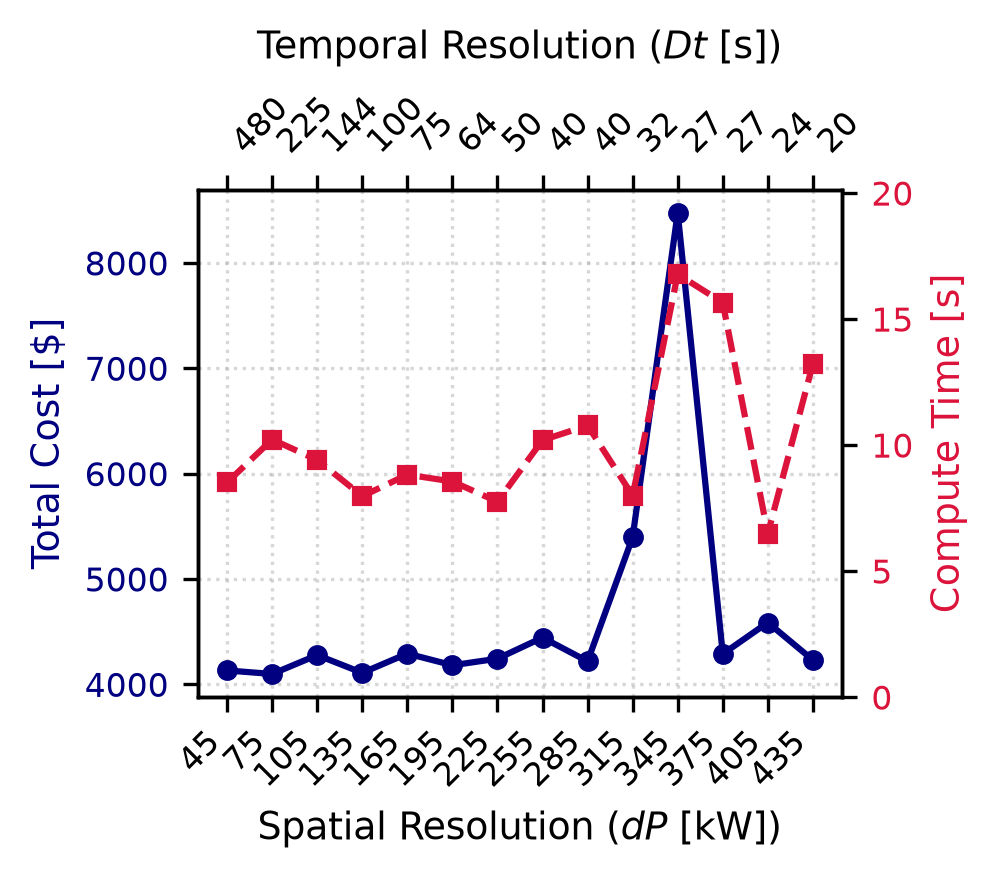

In [12]:
# Safely extract the columns (Handles both Flat and MultiIndex DataFrames)
df_plot = df_iso.reset_index() if 'dP [kW]' not in df_iso.columns else df_iso

dp_vals = df_plot['dP [kW]'].values
dt_vals = df_plot['Dt [s]'].values
costs = df_plot['Total Cost [$]'].values
times = df_plot['Offline Compute Time [s]'].values

# THE FIX: Create a strict, evenly-spaced integer array for the X-coordinates
x_positions = np.arange(len(dp_vals)) 

fig, ax_cost = plt.subplots(figsize=(3.5, 3.0)) # Slightly taller for double labels

# 1. Left Y-Axis & Bottom X-Axis (Cost vs dP)
color_cost = 'navy'
ax_cost.plot(x_positions, costs, 'o-', color=color_cost, lw=1.5, ms=4)
ax_cost.set_xlabel('Spatial Resolution ($dP$ [kW])')
ax_cost.set_ylabel('Total Cost [$]', color=color_cost)
ax_cost.tick_params(axis='y', labelcolor=color_cost)

# Explicitly apply the integer ticks, but label them with dP values
ax_cost.set_xticks(x_positions)
ax_cost.set_xticklabels([f"{int(x)}" for x in dp_vals], rotation=45, ha='right')
ax_cost.grid(True, ls=':', alpha=0.5)

# 2. Right Y-Axis (Compute Time)
color_time = 'crimson'
ax_time = ax_cost.twinx()
ax_time.plot(x_positions, times, 's--', color=color_time, lw=1.5, ms=4)
ax_time.set_ylabel('Compute Time [s]', color=color_time)
ax_time.tick_params(axis='y', labelcolor=color_time)

# Set symmetric/clean limits for the Y-axes to make the "bowl" pop
ax_time.set_ylim([0, max(times) * 1.2])

# 3. Top X-Axis (Dt matching dP)
ax_dt = ax_cost.twiny()
# Lock the top axis limits to match the bottom integer axis perfectly
ax_dt.set_xlim(ax_cost.get_xlim())
# Apply the exact same integer ticks, but label them with Dt values
ax_dt.set_xticks(x_positions)
ax_dt.set_xticklabels([f"{int(x)}" for x in dt_vals], rotation=45, ha='left')
ax_dt.set_xlabel('Temporal Resolution ($Dt$ [s])', labelpad=8)

# Adjust layout to prevent labels from getting cut off during save
plt.tight_layout()

# Save and Show
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/03_iso_complexity_crossover.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
costs

array([4131.10102226, 4108.56687481, 4242.9065386 , 5395.78659194,
       4586.22118251])

In [ ]:
# 3. Part B: 1D Spatial Resolution (dP) Sweep
dp_sweep_range = range(50,155,10)
dp_results = []

print("\n--- RUNNING PART B: 1D SPATIAL SENSITIVITY (dP) ---")
for dp in dp_sweep_range:
    cfg = SimConfig(
        dP=dp, Dt=Dt_base, N_Pd=N_PD, use_smart_grid=True, n_pack=N_PACK,
        apply_terminal_n_cost=False, apply_terminal_soc_cost=True, alpha_fc=4
    )
    bm = VoyageBenchmarker(fleet_data, env, cfg, exclude_days)
    report = bm.run_leave_one_out(value_factory)
    avg = report.summary.loc['Average']
    dp_results.append({
        'dP [kW]': dp,
        'Total Cost [$]': avg['Total Cost [$]'],
        'Offline Compute Time [s]': avg['Offline Compute Time [s]']
    })

df_dp = pd.DataFrame(dp_results).set_index('dP [kW]')
print_markdown_table(df_dp)


--- RUNNING PART B: 1D SPATIAL SENSITIVITY (dP) ---

⚙️  EMS Configuration Loaded | Smart Grid: ON
 -> dP Step Size       : 50 kW
 -> Module packs size  : 4 modules
 -> Grid Dimensions    : N_d=5, N_n=4, N_soc=73, N_fc=49, N_bat=41
 -> Augmented Space |S|: 71,540 states
 -> Action Space |A|   : 164 actions
 -> Time steps   : 288 steps/day
 -> Est. Big-O Comput. : O(3,481,994,880) operations / day
 -> Est. RAM Footprint : ~394.35 MB

 [Vault] Cache MISS: Training Markov Chain for days [5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
 [Vault] Cache MISS: Solving SDP(AugmentedHybridSDPSolver)
 [Vault] Cache MISS: Training Markov Chain for days [4, 6, 7, 8, 9, 10, 11, 12, 13, 14]
 [Vault] Cache MISS: Solving SDP(AugmentedHybridSDPSolver)
 [Vault] Cache MISS: Training Markov Chain for days [4, 5, 7, 8, 9, 10, 11, 12, 13, 14]
 [Vault] Cache MISS: Solving SDP(AugmentedHybridSDPSolver)
 [Vault] Cache MISS: Training Markov Chain for days [4, 5, 6, 8, 9, 10, 11, 12, 13, 14]
 [Vault] Cache MISS: Solving SDP(

In [ ]:
# 4. Part C: 1D Temporal Resolution (Dt) Sweep
dt_sweep_range = [60, 120, 180, 240, 300, 360, 480, 600]
dt_results = []

print("\n--- RUNNING PART C: 1D TEMPORAL SENSITIVITY (Dt) ---")
for dt in dt_sweep_range:
    cfg = SimConfig(
        dP=dP_base, Dt=dt, N_Pd=N_PD, use_smart_grid=True, n_pack=N_PACK,
        apply_terminal_n_cost=False, apply_terminal_soc_cost=True, alpha_fc=4
    )
    bm = VoyageBenchmarker(fleet_data, env, cfg, exclude_days)
    report = bm.run_leave_one_out(value_factory)
    avg = report.summary.loc['Average']
    dt_results.append({
        'Dt [s]': dt,
        'Total Cost [$]': avg['Total Cost [$]'],
        'Offline Compute Time [s]': avg['Offline Compute Time [s]']
    })

df_dt = pd.DataFrame(dt_results).set_index('Dt [s]')
print_markdown_table(df_dt)


--- RUNNING PART C: 1D TEMPORAL SENSITIVITY (Dt) ---

⚙️  EMS Configuration Loaded | Smart Grid: ON
 -> dP Step Size       : 100.0 kW
 -> Module packs size  : 4 modules
 -> Grid Dimensions    : N_d=5, N_n=4, N_soc=181, N_fc=25, N_bat=21
 -> Augmented Space |S|: 90,500 states
 -> Action Space |A|   : 84 actions
 -> Time steps   : 1,440 steps/day
 -> Est. Big-O Comput. : O(11,598,480,000) operations / day
 -> Est. RAM Footprint : ~2487.38 MB

 [Vault] Cache MISS: Training Markov Chain for days [5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
 [Vault] Cache MISS: Solving SDP(AugmentedHybridSDPSolver)
 [Vault] Cache MISS: Training Markov Chain for days [4, 6, 7, 8, 9, 10, 11, 12, 13, 14]
 [Vault] Cache MISS: Solving SDP(AugmentedHybridSDPSolver)
 [Vault] Cache MISS: Training Markov Chain for days [4, 5, 7, 8, 9, 10, 11, 12, 13, 14]
 [Vault] Cache MISS: Solving SDP(AugmentedHybridSDPSolver)
 [Vault] Cache MISS: Training Markov Chain for days [4, 5, 6, 8, 9, 10, 11, 12, 13, 14]
 [Vault] Cache MISS: Solv

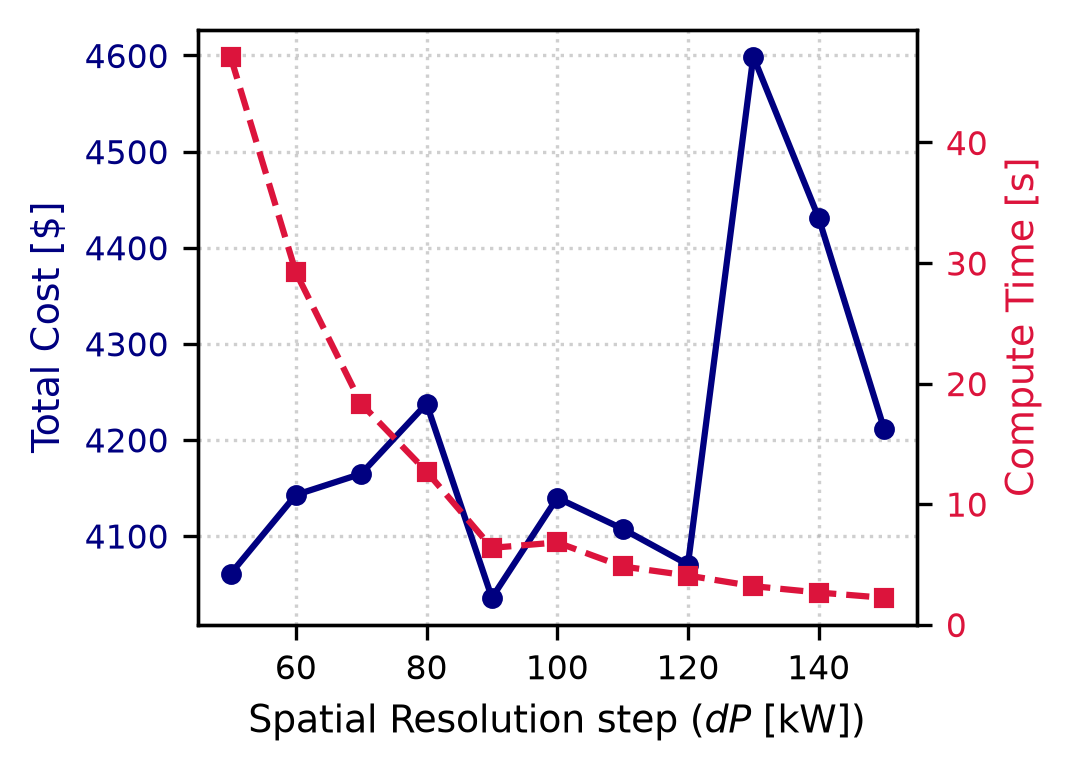

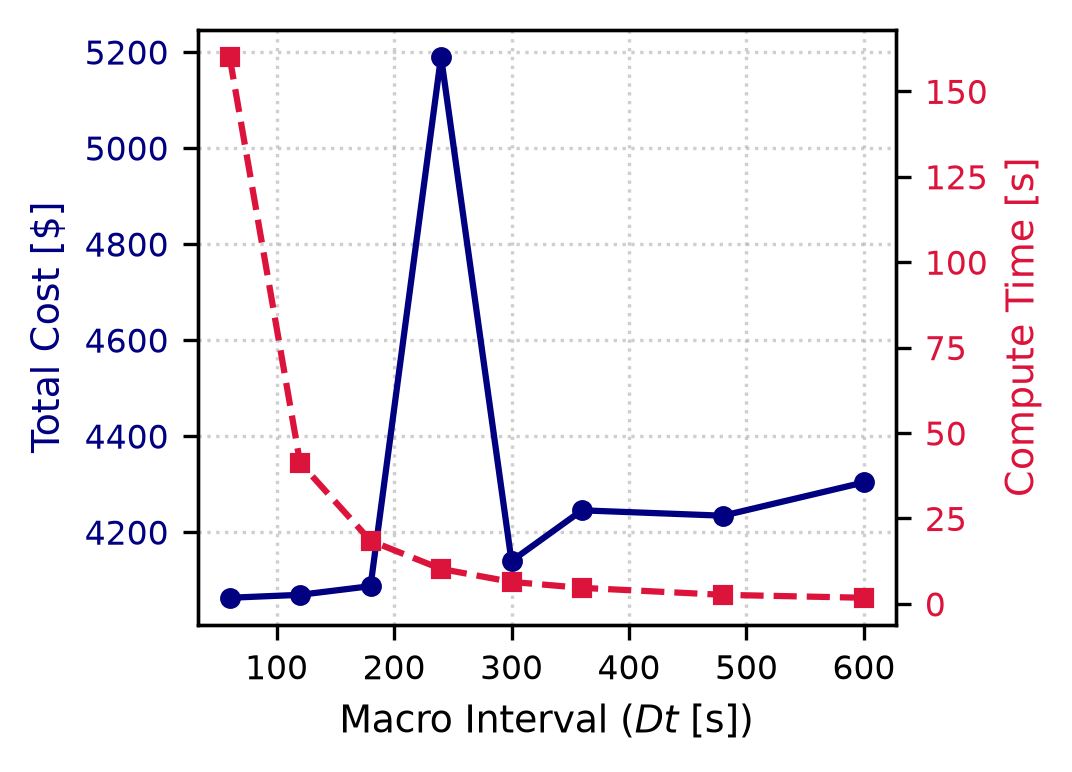

In [ ]:
# 5. Plotting 1D Twin-Axis L-Curves (Single Column Width: 3.5 inches)
os.makedirs('figures', exist_ok=True)

# Figure A: dP Sensitivity
fig, ax1 = plt.subplots(figsize=(3.5, 2.5))
ax1.plot(df_dp.index, df_dp['Total Cost [$]'], 'o-', color='navy', lw=1.5, ms=4, label='Cost')
ax1.set_xlabel('Spatial Resolution step ($dP$ [kW])')
ax1.set_ylabel('Total Cost [$]', color='navy')
ax1.tick_params(axis='y', labelcolor='navy')
ax1.grid(True, ls=':', alpha=0.6)

ax2 = ax1.twinx()
ax2.plot(df_dp.index, df_dp['Offline Compute Time [s]'], 's--', color='crimson', lw=1.5, ms=4, label='Time')
ax2.set_ylabel('Compute Time [s]', color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')

plt.tight_layout(pad=0.5)
plt.savefig('figures/03_dp_sensitivity_lcurve.png')
plt.show()

# Figure B: Dt Sensitivity
fig, ax1 = plt.subplots(figsize=(3.5, 2.5))
ax1.plot(df_dt.index, df_dt['Total Cost [$]'], 'o-', color='navy', lw=1.5, ms=4)
ax1.set_xlabel('Macro Interval ($Dt$ [s])')
ax1.set_ylabel('Total Cost [$]', color='navy')
ax1.tick_params(axis='y', labelcolor='navy')
ax1.grid(True, ls=':', alpha=0.6)

ax2 = ax1.twinx()
ax2.plot(df_dt.index, df_dt['Offline Compute Time [s]'], 's--', color='crimson', lw=1.5, ms=4)
ax2.set_ylabel('Compute Time [s]', color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')

plt.tight_layout(pad=0.5)
plt.savefig('figures/03_dt_sensitivity_lcurve.png')
plt.show()